# **Analisis Random Forest dan Logistic Regression**

Proyek ini bertujuan untuk memprediksi apakah seorang pasien kemungkinan akan terinfeksi AIDS berdasarkan statistik kesehatan dan informasi kategorikal pasien. Model prediktif ini bisa membantu tenaga medis dalam mengidentifikasi individu dengan risiko tinggi lebih awal, sehingga memungkinkan intervensi yang lebih efektif dan penggunaan sumber daya yang optimal.



Dataset diperoleh dari [Kaggle : AIDS Virus Infection Prediction 💉](https://www.kaggle.com/datasets/aadarshvelu/aids-virus-infection-prediction/data)

Proyek ini diharapkan memberikan wawasan tentang atribut pasien yang berhubungan dengan risiko infeksi yang lebih tinggi. Dengan model yang akurat, penyedia layanan kesehatan dapat mengidentifikasi individu berisiko tinggi dengan lebih efisien, mendukung strategi pencegahan dan intervensi.

Paper yang sedang kami buat mengenai penelitian ini : [Analisis Perbandingan Model Random Forest dan Logistic Regression untuk Prefiksi Risiko AIDS](https://uph365-my.sharepoint.com/:w:/g/personal/01082230009_student_uph_edu/Ed_BW5P-w65Nr38FSAhdoIgBG3fWGqUdo94G6_lKJm_cjg?e=ezRhfZ)

# **BAB 1: Pengumpulan Data & *Preprocessing***

## **1.1 Import Library & Dataset**

Library yang dibutuhkan saat menjalankan *pre-processing*:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('AIDS_Classification.csv')

Kode tersebut untuk membaca *dataset* lalu mengubahnya  menjadi *DataFrame* (df).

`df.head()` pada kode di bawah untuk menampilkan 5 baris pertama dari df.

In [ ]:
df.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


Berikut adalah fitur-fitur yang ada di dalam dataset beserta dengan penjelasannya masing-masing dan `df.info()`untuk melihat informasi dataset.

| **Nama Feature** | **Penjelasan Feature** |
|------------------|-----------------------|
| **time**  | Waktu hingga kegagalan atau pencatatan data |
| **trt**      | indikator pengobatan (0 = hanya ZDV; 1 = ZDV + ddI, 2 = ZDV + Zal, 3 = hanya ddI) |
| **age**     | usia (tahun) pada awal penelitian |
| **wtkg**     | berat badan (kg) pada awal penelitian |
| **hemo**     | hemofilia (0=tidak, 1=ya) |
| **homo**     | aktivitas homoseksual (0=tidak, 1=ya) |
| **drugs**       | riwayat penggunaan narkoba IV (0=tidak, 1=ya) |
| **karnof**       | skor Karnofsky (skala 0-100) |
| **oprior**     | terapi antiretroviral non-ZDV sebelum 175 (0=tidak, 1=ya) |
| **z30**  | ZDV dalam 30 hari sebelum 175 (0=tidak, 1=ya) |
| **preanti**       | jumlah hari terapi antiretroviral sebelum 175 |
| **race**        | ras (0=Putih, 1=bukan Putih) |
| **gender**        | jenis kelamin (0=Perempuan, 1=Laki-laki) |
| **str2**        | riwayat antiretroviral (0=naif, 1=berpengalaman) |
| **strat**        | stratifikasi riwayat antiretroviral (1='Naif Antiretroviral', 2='> 1 tetapi <= 52 minggu terapi antiretroviral sebelumnya', 3='> 52 minggu') |
| **symptom**  | indikator gejala (0=asimtomatik, 1=simptomatik) |
| **treat**       | indikator pengobatan (0=hanya ZDV, 1=lainnya) |
| **offtrt**        | indikator penghentian pengobatan sebelum 96+/-5 minggu (0=tidak, 1=ya) |
| **cd40**        | CD4 pada awal penelitian |
| **cd420**        | CD4 pada 20+/-5 minggu |
| **cd80**        | CD8 pada awal penelitian |
| **cd820**        | CD8 pada 20+/-5 minggu |
| **infected**        | terinfeksi AIDS (0=Tidak, 1=Ya) |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      2139 non-null   int64  
 1   trt       2139 non-null   int64  
 2   age       2139 non-null   int64  
 3   wtkg      2139 non-null   float64
 4   hemo      2139 non-null   int64  
 5   homo      2139 non-null   int64  
 6   drugs     2139 non-null   int64  
 7   karnof    2139 non-null   int64  
 8   oprior    2139 non-null   int64  
 9   z30       2139 non-null   int64  
 10  preanti   2139 non-null   int64  
 11  race      2139 non-null   int64  
 12  gender    2139 non-null   int64  
 13  str2      2139 non-null   int64  
 14  strat     2139 non-null   int64  
 15  symptom   2139 non-null   int64  
 16  treat     2139 non-null   int64  
 17  offtrt    2139 non-null   int64  
 18  cd40      2139 non-null   int64  
 19  cd420     2139 non-null   int64  
 20  cd80      2139 non-null   int6

## **1.2 Memeriksa Duplicate Rows**

In [ ]:
df.shape

(2139, 23)

In [ ]:
duplicate_rows_df = df[df.duplicated()]
if duplicate_rows_df.empty:
    print("Tidak ada baris duplikat")
else:
    print("Number of duplicate rows:", duplicate_rows_df.shape[0])

Tidak ada baris duplikat


Tidak ada duplicated rows dalam dataset.

## **1.3 Memeriksa Missing Value**

In [ ]:
df.isnull().sum()

,0
time,0
trt,0
age,0
wtkg,0
hemo,0
homo,0
drugs,0
karnof,0
oprior,0
z30,0


Bisa dilihat bahwa dataset memiliki 2.139 entri dengan 23 kolom, tanpa nilai yang hilang (missing values).

##**1.4 Memeriksa Korelasi Antar Fitur**

In [ ]:
korelasi = df.corr()
korelasi

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
time,1.000000,0.101482,0.026544,0.009225,-0.017501,0.043430,-0.021856,0.094417,-0.016116,0.012898,...,0.010098,0.022033,-0.104611,0.153314,-0.475795,0.191436,0.350611,-0.017425,0.032480,-0.574989
trt,0.101482,1.000000,-0.001931,-0.031685,0.012329,0.025035,0.005712,-0.014573,-0.026805,-0.001656,...,-0.003003,-0.003508,-0.000765,0.775990,-0.043239,-0.012770,0.064448,-0.015665,-0.004595,-0.084360
age,0.026544,-0.001931,1.000000,0.132858,-0.231257,0.158917,0.077446,-0.100041,0.056161,0.061178,...,0.068230,0.089884,0.032814,0.001499,-0.057695,-0.040302,-0.044294,0.046874,0.037458,0.070384
wtkg,0.009225,-0.031685,0.132858,1.000000,-0.075791,0.155909,0.002343,0.034271,0.009607,-0.073841,...,-0.078885,-0.080458,0.003942,-0.040638,-0.003159,0.036401,0.020980,0.090075,0.085447,0.016205
hemo,-0.017501,0.012329,-0.231257,-0.075791,1.000000,-0.391307,-0.092957,0.068403,0.034978,0.111554,...,0.124983,0.141674,-0.076296,0.010786,0.005949,-0.022533,-0.065838,-0.037273,-0.058392,-0.011154
homo,0.043430,0.025035,0.158917,0.155909,-0.391307,1.000000,-0.206876,-0.042072,0.019743,-0.049760,...,-0.036700,-0.022608,0.118575,0.024407,-0.045151,0.000511,0.019915,0.086028,0.082284,0.054279
drugs,-0.021856,0.005712,0.077446,0.002343,-0.092957,-0.206876,1.000000,-0.084558,-0.029968,0.014961,...,0.001106,-0.011319,0.027052,0.022055,0.098031,-0.003360,0.013109,0.014900,0.025728,-0.049794
karnof,0.094417,-0.014573,-0.100041,0.034271,0.068403,-0.042072,-0.084558,1.000000,-0.057291,-0.074947,...,-0.085975,-0.055172,-0.107940,0.001379,-0.103251,0.077730,0.098463,-0.008567,-0.003981,-0.102944
oprior,-0.016116,-0.026805,0.056161,0.009607,0.034978,0.019743,-0.029968,-0.057291,1.000000,-0.037580,...,0.126040,0.134629,0.024199,-0.031801,0.019561,-0.059199,-0.109643,-0.019247,-0.036577,0.041251
z30,0.012898,-0.001656,0.061178,-0.073841,0.111554,-0.049760,0.014961,-0.074947,-0.037580,1.000000,...,0.903417,0.848624,0.020883,0.003776,-0.029318,-0.121282,-0.200149,0.029346,0.018454,0.125488


### **1.4.1 Visualisasi Korelasi Antar Fitur**

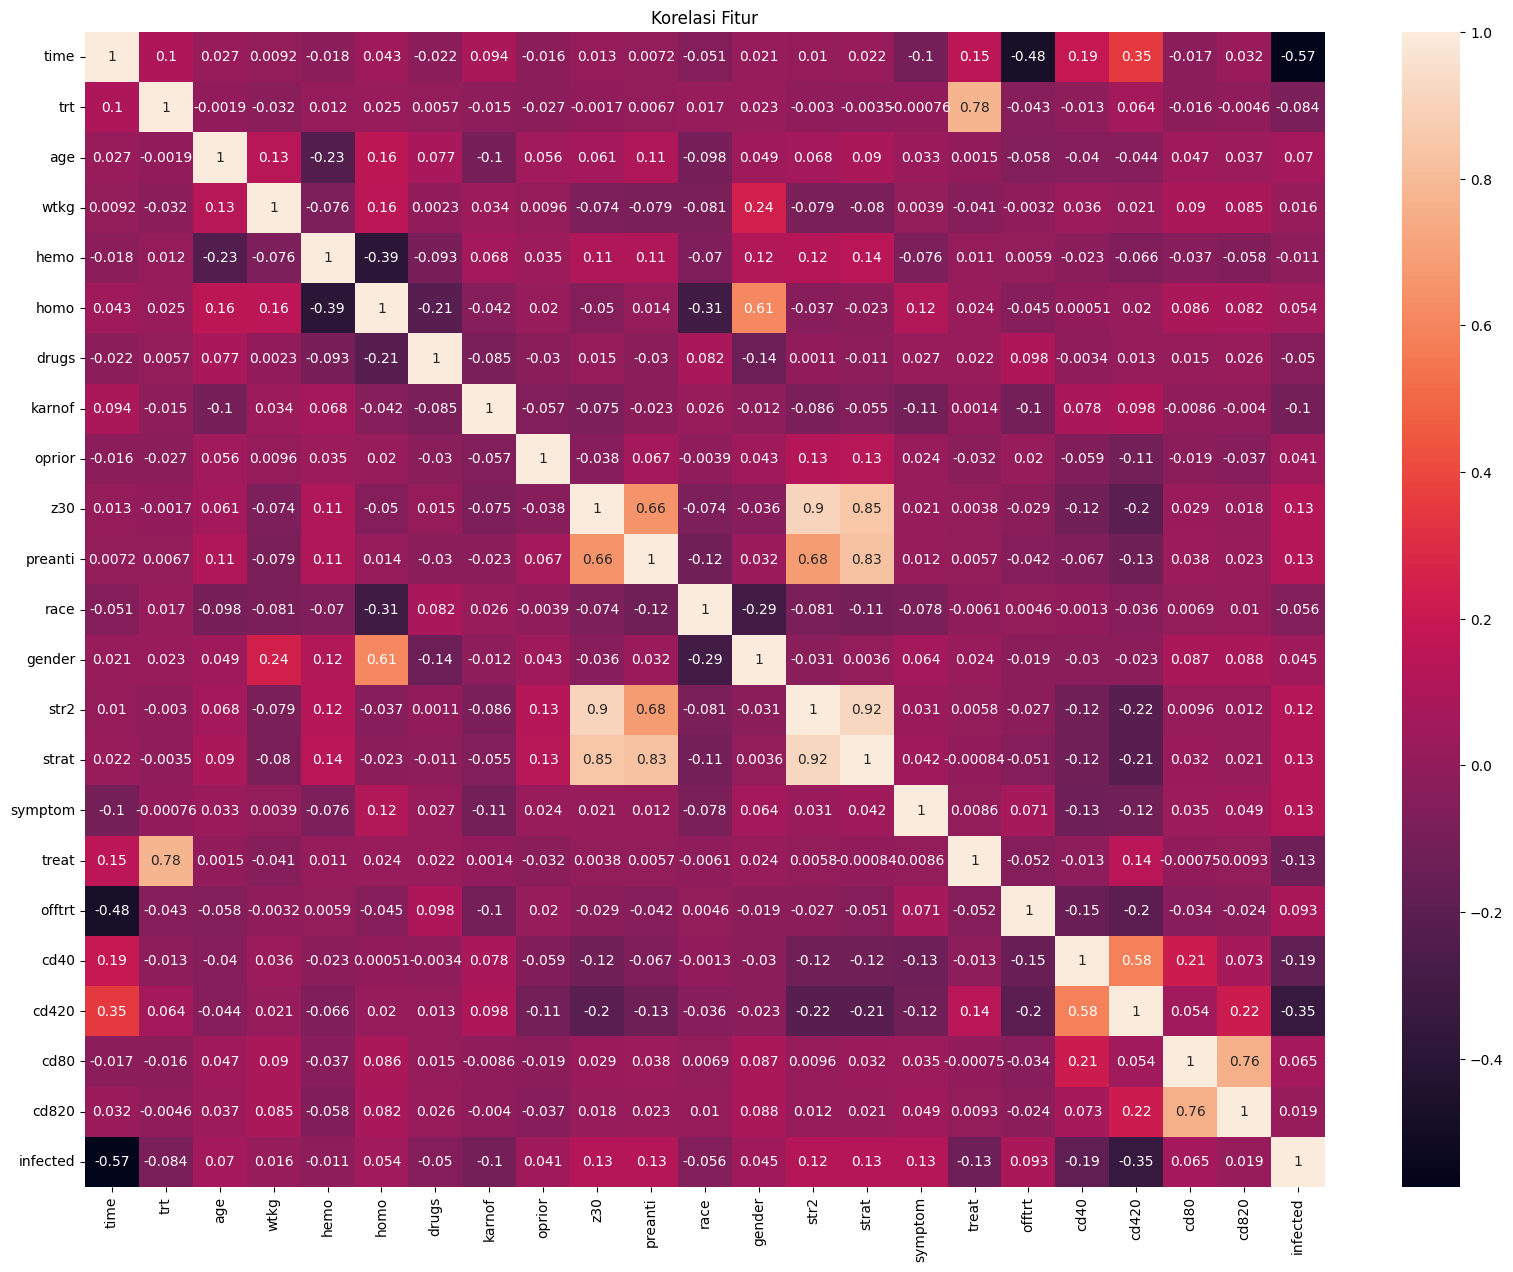

In [ ]:
sns.heatmap(korelasi, annot=True, annot_kws={'size': 10})
heat_map = plt.gcf()
heat_map.set_size_inches(20, 15)

plt.title('Korelasi Fitur')
plt.show()

Dari visualisasi korelasi, ditemukan bahwa ada beberapa fitur-fitur yang memiliki korelasi yang lebih besar dari 0.8 dan 0.9:

*   `str2` - `strat` = 0.92
*   `str2` - `z30` = 0.90
*   `strat` - `z30` = 0.85
*   `preanti` - `strat` =  0.83

Hal ini menunjukkan ada multikolinearitas tinggi yang perlu dikhawatirkan.

Maka, kita harus menghapus salah satu fitur yang kurang relevan atau memiliki korelasi rendah dengan target `infected`, yaitu fitur `str2` yang memiliki korelasi paling rendah 0,12 dengan target `infected`.

In [ ]:
# Drop fitur dengan korelasi tinggi
df.drop(['str2'], axis=1, inplace=True)

## **1.5 Mendeteksi & Menghapus Outliers**

Visualisasi data menggunakan scatter plot untuk membandingkan sebelum dan sesudah menghapus outlier yang terdapat dalam data.



Memeriksa jumlah data sebelum menghapus data outliers:

In [ ]:
df.shape

(2139, 22)

Contoh visualisasi pertama adalah fitur age yang belum dihapus outliernya

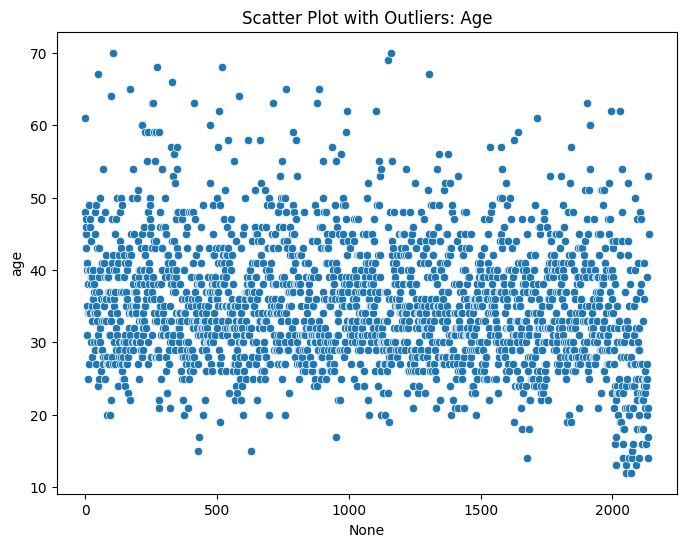

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.index, y=df['age'])
plt.title("Scatter Plot with Outliers: Age")
plt.show()

Kode di atas untuk menunjukkan visualisasi scatter plot dengan outlier.

Kode di bawah menghapus outliers (semua outliers yang terdapat di semua fitur dihapus secara bersamaan):

In [ ]:
from scipy.stats import zscore
z_scores = zscore(df.select_dtypes(include=['float64', 'int64']))
df = df[(np.abs(z_scores) < 3).all(axis=1)]

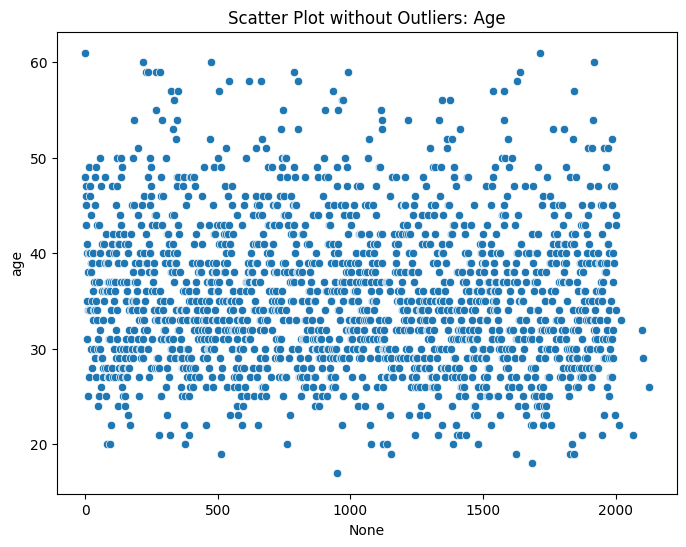

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.index, y=df['age'])
plt.title("Scatter Plot without Outliers: Age")
plt.show()

In [ ]:
df.shape

(1795, 22)

Bentuk visualisasi setelah menghapus outlier, terlihat bahwa visualisasi ini lebih rapi setelah menghapus outlier. Setelah menghapus outlier, data tersebut berkurang menjadi 1.795.

## **1.6 Penanganan Ketidaseimbangan Data (SMOTE)**

In [ ]:
# pemisahan predictor feature dan target feature
X = df.drop(['infected'], axis=1)
y = df['infected']

kode di atas harus  dipisahkan karena `infected` menjadi target (y) untuk memprediksi. `infected` harus di pisahkan dari X agar model dapat dilatih secara benar dan menghindari data *leakage* (situasi dalam proses *machine learning* di mana informasi dari dataset yang seharusnya tidak tersedia saat model dilatih justru ikut terbawa dalam proses pelatihan. Hal ini menyebabkan model tampak sangat akurat saat diuji menggunakan data pelatihan, tetapi performanya buruk saat digunakan pada data baru (*real-world* data)). Hasil prediksi yang di harapkan adalah tidak terinfeksi (0) dan terinfeksi (1).



In [ ]:
from imblearn.over_sampling import SMOTE
# Memeriksa keseimbangan data
print(df['infected'].value_counts(normalize=True))

infected
0    0.762117
1    0.237883
Name: proportion, dtype: float64


<ipython-input-20-9270548f54b1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


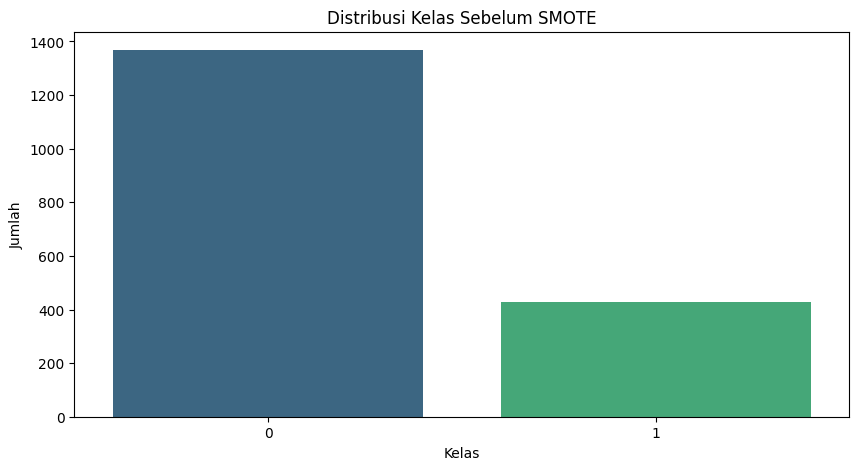

In [ ]:
# Visualisasi Sebelum SMOTE
plt.figure(figsize=(10, 5))
sns.countplot(x=y, palette="viridis")
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

Menggunakan teknik SMOTE untuk menyeimbangkan kelas, karena proporsi data menunjukkan ketidakseimbangan dengan mayoritas sampel pada kelas tidak terinfeksi.

In [ ]:
# Splitting Dataset untuk implementasi SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
# Mengecek hasil SMOTE
print(y_train_balanced.value_counts(normalize=True))

infected
0    0.5
1    0.5
Name: proportion, dtype: float64


<ipython-input-24-2b22a34ef7b4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced, palette="viridis")


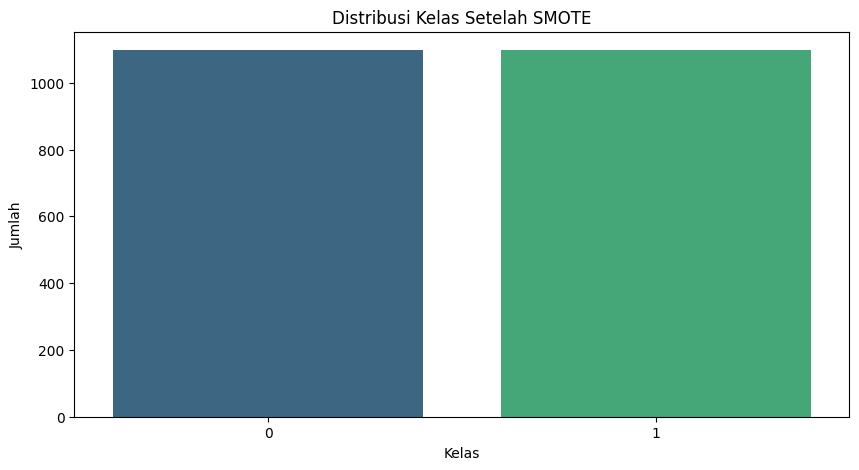

In [ ]:
# Visualisasi Setelah SMOTE
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_balanced, palette="viridis")
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

In [ ]:
df.shape

(1795, 22)

Teknik SMOTE menghasilkan distribusi kelas yang seimbang (50% untuk setiap kelas), yang penting untuk menghindari bias model terhadap kelas mayoritas.

## **1.7 standardization / normalization / feature scaling:**

Normalisasi dilakukan untuk meningkatkan performa model berbasis jarak dan algoritma yang sensitif terhadap skala data.

In [ ]:
scaler = StandardScaler()
X_train_balanced = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

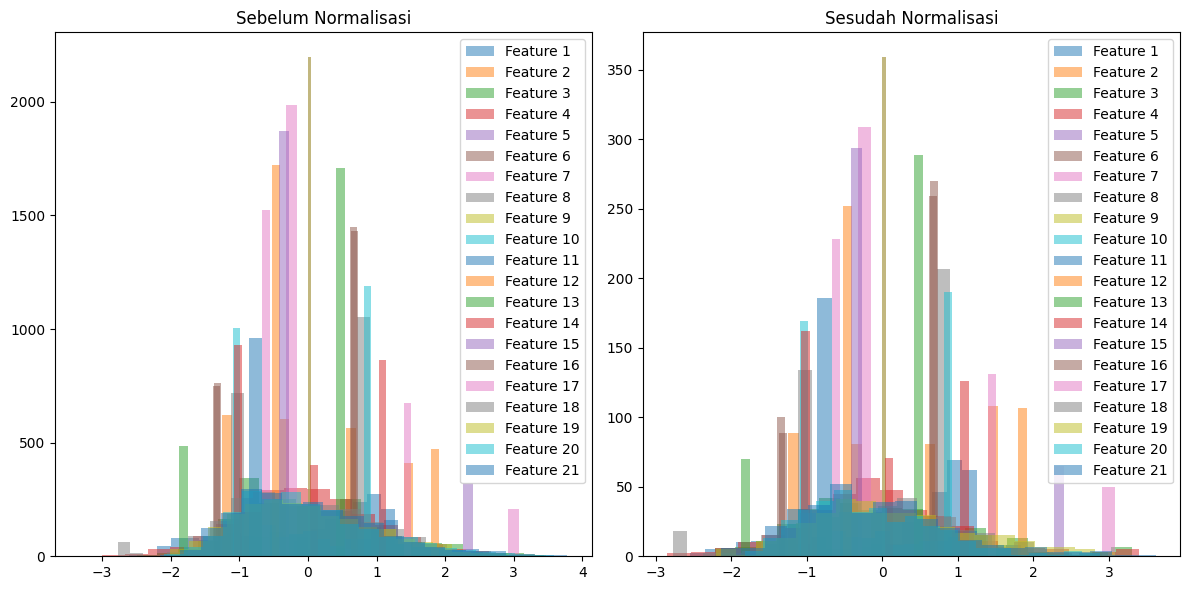

In [ ]:
plt.figure(figsize=(12, 6))

# Sebelum normalisasi
plt.subplot(1, 2, 1)
for i in range(X_train_balanced.shape[1]):
    plt.hist(X_train_balanced[:, i], bins=20, alpha=0.5, label=f"Feature {i+1}")
plt.title("Sebelum Normalisasi")
plt.legend()

# Sesudah normalisasi
plt.subplot(1, 2, 2)
for i in range(X_test_scaled.shape[1]):
    plt.hist(X_test_scaled[:, i], bins=20, alpha=0.5, label=f"Feature {i+1}")
plt.title("Sesudah Normalisasi")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1795 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      1795 non-null   int64  
 1   trt       1795 non-null   int64  
 2   age       1795 non-null   int64  
 3   wtkg      1795 non-null   float64
 4   hemo      1795 non-null   int64  
 5   homo      1795 non-null   int64  
 6   drugs     1795 non-null   int64  
 7   karnof    1795 non-null   int64  
 8   oprior    1795 non-null   int64  
 9   z30       1795 non-null   int64  
 10  preanti   1795 non-null   int64  
 11  race      1795 non-null   int64  
 12  gender    1795 non-null   int64  
 13  strat     1795 non-null   int64  
 14  symptom   1795 non-null   int64  
 15  treat     1795 non-null   int64  
 16  offtrt    1795 non-null   int64  
 17  cd40      1795 non-null   int64  
 18  cd420     1795 non-null   int64  
 19  cd80      1795 non-null   int64  
 20  cd820     1795 non-null   int64  
 

In [ ]:
df.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,gender,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,0,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


# **BAB 2: Melatih Model**

## **2.1 Random Forest**

In [ ]:
import sklearn.tree as tree
import sklearn.ensemble as ens
import sklearn.metrics as met
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report

Library yang dibutuhkan untuk membuat model.

### **2.1.1 Training Data**

In [ ]:
# Parameter grid untuk tuning
param_dist = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
}

# Membuat Model Random Forest
rf_classifier = RandomForestClassifier(random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    refit='f1',
    random_state=42,
    n_jobs=-1
)

# Lakukan tuning pada data pelatihan
random_search.fit(X_train_balanced, y_train_balanced)

# Memakai Parameter terbaik dari RandomizedSearchCV
best_rf_classifier = random_search.best_estimator_

# Memakai parameter terbaik di data testing
y_pred = best_rf_classifier.predict(X_test_scaled)

# Menampilkan hasil terbaik
print("Best parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

accuracy_test = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", accuracy_test)
f1_test = f1_score(y_test, y_pred, average='weighted')
print("F1-weighted on test set:", f1_test)

Best parameters: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'gini', 'bootstrap': False}
Best Score: 0.9324708673874355
Accuracy on test set: 0.8857938718662952
F1-weighted on test set: 0.886421319960613


kode di atas untuk menjalankan hyperparameter tuning (RandomizedSearchCV) agar dapat menemukan parameter terbaik dalam waktu singkat. 5 cv = 8 menit




In [ ]:
rf_model = ens.RandomForestClassifier(n_estimators=1000,
                                      criterion='gini',
                                      min_samples_split=5,
                                      min_samples_leaf=1,
                                      max_features='sqrt',
                                      max_depth=20,
                                      bootstrap=False)
rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(bootstrap=False, max_depth=20, min_samples_split=5,
                       n_estimators=1000)

kode untuk membuat model Random Forest dan melatih nya memakai parameter terbaik.

### **2.1.2 Testing Data**

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Hasil Prediksi:", y_pred_rf[:20])
print("Label Asli    :", y_test.values[:20])

Hasil Prediksi: [1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1]
Label Asli    : [1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 1]


kode di atas untuk mengujikan hasil prediksi dan membandingkannya dengan label asli (data asli) yang sudah dinormalisasi dan diseimbangkan.

In [ ]:
print('Akurasi = ', met.accuracy_score(y_test, y_pred_rf),'\n')
print(met.classification_report(y_test, y_pred_rf))
print('Skor Kepentingan Fitur = ',rf_model.feature_importances_)

Akurasi =  0.8969359331476323 

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       270
           1       0.79      0.80      0.79        89

    accuracy                           0.90       359
   macro avg       0.86      0.86      0.86       359
weighted avg       0.90      0.90      0.90       359

Skor Kepentingan Fitur =  [0.45070054 0.01821232 0.02903996 0.03459689 0.         0.00819065
 0.01458277 0.04790264 0.         0.00533344 0.03450964 0.02995898
 0.00470351 0.00982867 0.00439778 0.02871501 0.04197324 0.0481749
 0.11801536 0.03612034 0.03504338]


Kode di atas menunjukkan Performa dari model tersebut.

*   Akurasi = 0,89 (nilai pembulatan menjadi 0,90)
*   Performa menurut weighted avg:
    *   Precision = 0,90
    *   recall = 0,90
    *   F1-score = 0,90




## **2.2 Logistics Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

Library yang dibutuhkan untuk membuat model.

### **2.2.1 Training Data**

In [ ]:
param_grid_lr = [
    {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
     'penalty': ['l2'],
     'solver': ['lbfgs', 'newton-cg'],
     'max_iter': [100, 500, 1000],
     'class_weight': [None, 'balanced']},

    {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
     'penalty': ['l1', 'l2'],
     'solver': ['liblinear', 'saga'],
     'max_iter': [100, 500, 1000],
     'class_weight': [None, 'balanced']}
]

# Membuat Model Logistic Regression
lr_classifier = LogisticRegression(random_state=42)

# Membuat GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr_classifier, param_grid=param_grid_lr, cv=10, scoring='f1_weighted', refit='f1', n_jobs=-1)

# Lakukan tuning pada data pelatihan
grid_search_lr.fit(X_train_balanced, y_train_balanced)

# Menampilkan parameters dan score terbaik
print("Best parameters (Logistic Regression):", grid_search_lr.best_params_)
print("Best score (Logistic Regression):", grid_search_lr.best_score_)

# Memakai parameter terbaik untuk data testing
best_lr_classifier = grid_search_lr.best_estimator_

# Menampilkan hasil performa
y_pred_lr = best_lr_classifier.predict(X_test_scaled)
accuracy_lr = met.accuracy_score(y_test, y_pred_lr)
print(f"Accuracy on test set (Logistic Regression): {accuracy_lr}")
f1_lr = met.f1_score(y_test, y_pred_lr, average='weighted')
print(f"F1 on test set (Logistic Regression): {f1_lr}")

Best parameters (Logistic Regression): {'C': 0.1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best score (Logistic Regression): 0.8803279061007654
Accuracy on test set (Logistic Regression): 0.8607242339832869
F1 on test set (Logistic Regression): 0.8612391113504285


kode di atas untuk menjalankan hyperparameter tuning (GridSearchCV) agar dapat menemukan parameter terbaik untuk memprediksi. 5 cv = 1 menit



In [ ]:
lr_model = LogisticRegression(random_state=42, C=0.1, class_weight=None, max_iter=100, penalty='l1', solver='liblinear',
                              )
lr_model.fit(X_train_balanced, y_train_balanced)

LogisticRegression(C=0.1, penalty='l1', random_state=42, solver='liblinear')

kode untuk membuat model Logistic Regression dan melatih nya menggunakan parameter terbaik.

### **2.2.2 *Testing Data***

In [ ]:
y_pred_log = lr_model.predict(X_test_scaled)

print("Hasil Prediksi:", y_pred_log[:20])
print("Label Asli    :", y_test.values[:20])

Hasil Prediksi: [0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1]
Label Asli    : [1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 1]


kode tersebut untuk mengujikan hasil prediksi dan membandingkannya dengan label asli (data asli) yang sudah dinormalisasi dan diseimbangkan.

In [ ]:
print('Akurasi = ', met.accuracy_score(y_test, y_pred_log),'\n')
print(met.classification_report(y_test, y_pred_log))
print('Skor Kepentingan Fitur = ',lr_model.coef_)

Akurasi =  0.8607242339832869 

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       270
           1       0.71      0.73      0.72        89

    accuracy                           0.86       359
   macro avg       0.81      0.82      0.81       359
weighted avg       0.86      0.86      0.86       359

Skor Kepentingan Fitur =  [[-2.16846176 -0.08263158  0.          0.12640646  0.         -0.24902372
  -0.37553239 -0.16862093  0.          0.          0.12549161 -0.61015
   0.          0.          0.         -0.18413876 -1.12930731 -0.02032076
  -0.72679804  0.          0.08696974]]


Kode di atas menunjukkan Performa dari model tersebut.

*   Akurasi = 0,86
*   Performa menurut weighted avg:
   *   Precision = 0.86
   *   recall = 0.86
   *   F1-score = 0.86




# **BAB 3: Kesimpulan**

Setelah melihat hasil performa model, kedua model tersebut mencapai performa di atas 85% yang berarti cukup baik. Namun performa model yang paling baik adalah Random Forest dengan akurasi 90%, sedangkan akurasi Logistics Regression mencapai 86%. Untuk weighted avg pada metrik precision, recall, dan f1-score di Random Forest mencapai 90% sedangkan Logistics Regression pada metrik precision, recall, dan f1-score mencapai 86%. Untuk keseluruhan, Random Forest menghasilkan performa yang lebih baik meskipun Logistics Regression lebih sering di gunakan dalam medis. Hal ini terjadi karena Random Forest dapat menangani data yang kompleks dari data AIDS_Classification.csv. Namun Logistics Regression masih bisa di pakai karena memiliki performa yang cukup baik untuk memprediksi terinfeksi atau tidak terinfeksi AIDS.